In [1219]:
# ======================
# packages
# ======================

# packages
from pathlib import Path
import ssl
from urllib import request
import ppxf.sps_util as lib
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS

import squirrel
from squirrel.data import Datacube, Spectra
from squirrel.pipeline import Pipeline

from scipy.interpolate import interp1d
from astropy.utils.masked.function_helpers import interp as astropy_interp

import pandas as pd

from ppxf.ppxf import robust_sigma

from importlib import resources

from ppxf.ppxf import ppxf
from ppxf.ppxf_util import log_rebin, vac_to_air, air_to_vac
import ppxf.ppxf_util as util

import pickle as pkl

base = Path.cwd()

# speed of light
c = 299792.458 # km/s (everything ppxf outputs is in km/s)

cwd = Path.cwd()
gen_dir = os.path.join(cwd, '..', 'data/')
print(gen_dir)

"""obj = 'DESJ0206'
filter = 'r'
z_defl = 0.6754645040466052 # after running to get exact redshift from ppxf, updated from 0.675 to 0.675302186977028
z_src = 1.302

wavelength_min = 3800
wavelength_max = 5250"""

obj = 'DESJ2112'
filter = 'r'
z_defl = 0.44527499
z_src = 2.359

rest_absorption_lines_etg = {"": 3933.7, "Ca H" : 3968.5, "Ca G" : 
                             4307.74, "Mg I" : 5175.0, "Na": 5895.92}


# wavelength range
"""wavelength_min = rest_absorption_lines_etg["Na"] - 20
wavelength_max = rest_absorption_lines_etg["Na"] + 21"""
wavelength_min = 4000
wavelength_max = 6001

/Users/william0billy/Research/DynamicalModeling/codes/../data/


In [1220]:
# ======================
# Create Spectra object from the integrated spectrum of the deflector
# ======================

# spectra and cube paths
spectrum_path = gen_dir + f'{obj}_integrated_defl_{filter}.fits'
cube_path = gen_dir + f'{obj}_{filter}.fits'
noise_path = gen_dir + f'{obj}_integrated_var_{filter}.fits'

# open spectrum to get flux, get noise as well
deflector_spectrum = fits.open(spectrum_path)[0].data / np.median(fits.open(spectrum_path)[0].data) # integrated deflector spectrum, normalized by median flux
noise_spectrum = np.sqrt(fits.open(noise_path)[0].data) / np.median(fits.open(spectrum_path)[0].data) # integrated noise spectrum

# open cube to extract wcs info and wavelength array
with fits.open(cube_path) as hdul:
    cube = hdul[0].data
    hdr = hdul[0].header
    wcs = WCS(hdr)

# build wavelength array in air wavelengths (need to convert), but do not convert to rest frame
ref_lambda = hdr['CRVAL3'] # wavelength zeropoint (beginning wavelength)
if filter == 'r':
    delt = hdr['CD3_3'] # wavelength step size
else:
    delt = hdr['CDELT3'] # wavelength step size (1.0 angstroms per pixel)
npix = hdr['NAXIS3'] # number of wavelength pixels
pix = np.arange(npix) # pixel indices
crpix = hdr.get('CRPIX3', 1.0) # reference pixel (default to 1.0 if not present)
wavelengths = ref_lambda + (pix - crpix) * delt # wavelength array

wavelength_vac = ref_lambda + delt * np.arange(npix) # in angstrom, ref_lambda is start, delt is step size, npix is number of pixels
wavelength_air = vac_to_air(wavelength_vac) # convert to air wavelengths, send to rest frame\

# obtain the FWHM of the instrument using the nominal resolution and central KCRM wavelength
RM_central =  (wavelength_min + wavelength_max) * (1+z_defl) / 2 # AA
R = 1700 # KCRM resolution, see email Rosalie sent
fwhm_gal = RM_central / R # use uniform fwhm


integrated_spectrum = Spectra(wavelengths = wavelength_air,
                              flux = deflector_spectrum,
                              wavelength_unit = 'AA',
                              fwhm = fwhm_gal,
                              z_lens = z_defl,
                              z_source = z_src,
                              noise = noise_spectrum)

# ======================
# spectra modifications
# ======================

# deredshift
integrated_spectrum.deredshift(target_frame = 'lens')

# apply wavelength cuts
integrated_spectrum.clip(wavelength_min, wavelength_max)

print(integrated_spectrum.spectra_modifications, integrated_spectrum.wavelengths_frame)
print(f'Instrumental FWHM: {fwhm_gal:.2f} AA')
print(f'Deredshifted FWHM: {integrated_spectrum.fwhm:.2f} AA')

['clipped'] lens frame
Instrumental FWHM: 4.25 AA
Deredshifted FWHM: 2.94 AA


Set MJD-BEG to 60944.230916 from DATE-BEG.
Set MJD-END to 60944.234388 from DATE-END'. [astropy.wcs.wcs]


[0.00829165 0.00827271 0.00825124 ... 0.0078338  0.00738367 0.00699818]
[0.60833067 0.62368906 0.62075233 ... 1.152371   1.1442887  1.1167047 ]
161.02266


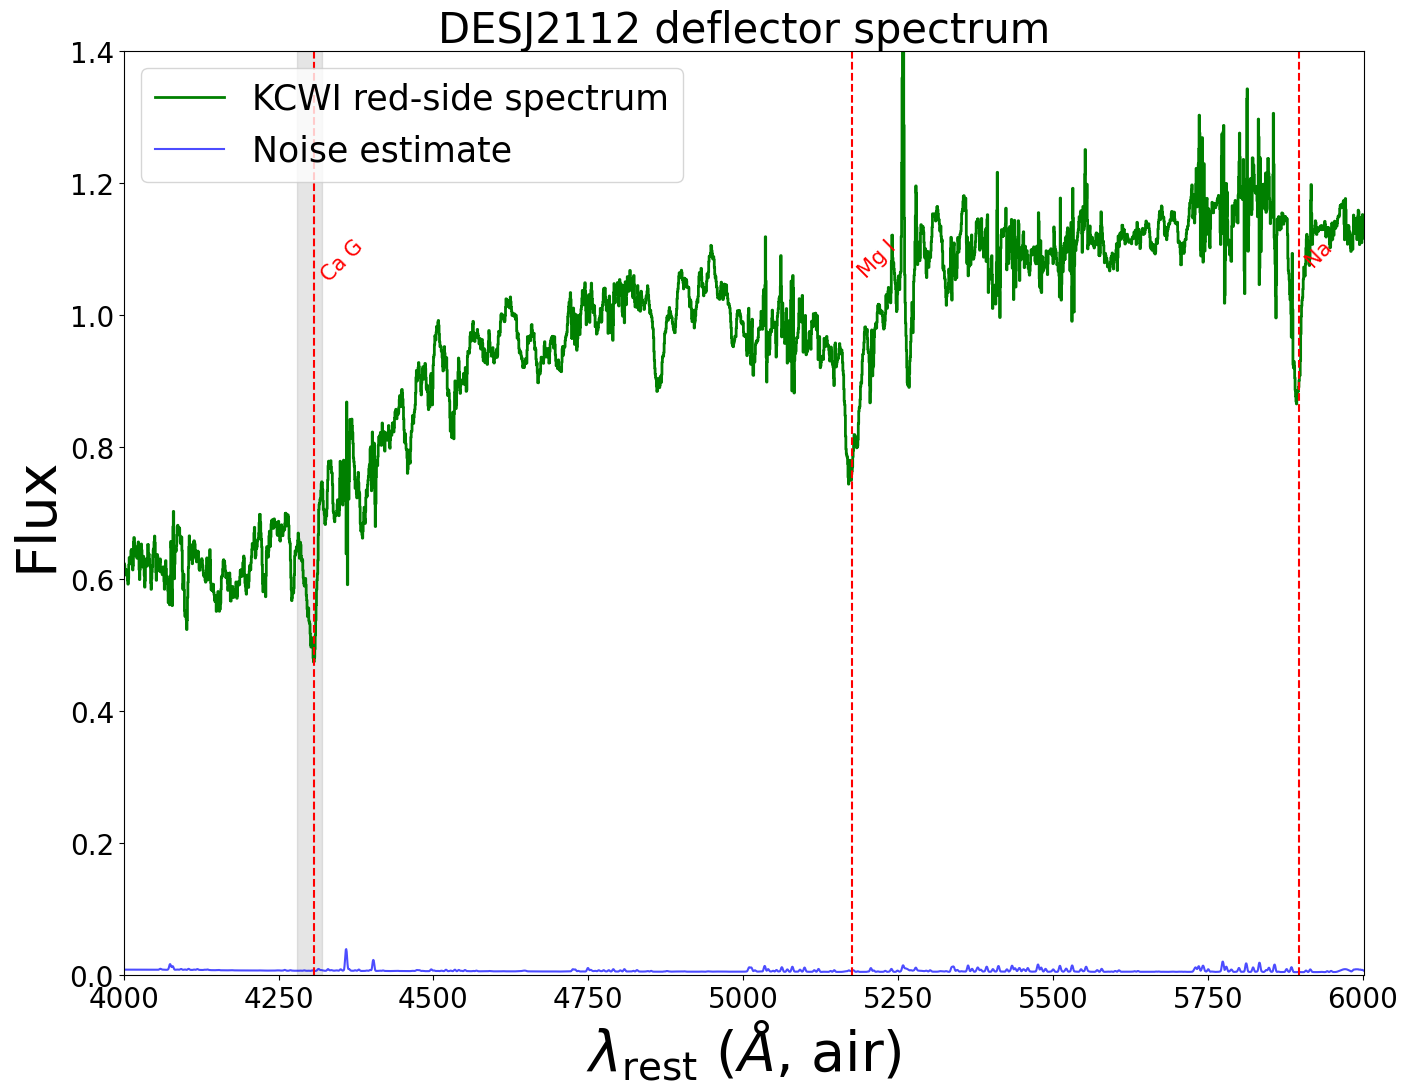

In [1221]:
# ======================
# Plot the integrated spectrum
# ======================

print(integrated_spectrum.noise)
print(integrated_spectrum.flux)

# absorption lines
rest_absorption_lines_etg = {"": 3933.7, "Ca H" : 3968.5, "Ca G" : 
                             4307.74, "Mg I" : 5175.0, "Na": 5895.92}


# plot the spectrum and noise
plt.figure(figsize=(16, 12))
plt.plot(integrated_spectrum.wavelengths, integrated_spectrum.flux, color='green', lw=2, label='KCWI red-side spectrum', drawstyle='steps-mid')
plt.plot(integrated_spectrum.wavelengths, integrated_spectrum.noise, color='blue', alpha=0.7, label='Noise estimate')

if filter == 'r':
    plt.xlim(wavelength_min, wavelength_max)
elif filter == 'b':
    plt.xlim(wavelength_min, wavelength_max)

plt.ylim(0, 1.4)

for line_name, line_wavelength in rest_absorption_lines_etg.items():
    if line_wavelength >= plt.xlim()[0] and line_wavelength <= plt.xlim()[1]:
        if line_name == "":
            plt.axvline(x=line_wavelength, color='red', linestyle='--', label = 'Absorption Feature')
        else:
            plt.axvline(x=line_wavelength, color='red', linestyle='--')
        plt.text(line_wavelength + 5, plt.ylim()[1] * 0.8, line_name, rotation=45, verticalalignment='top', horizontalalignment='left', fontsize=15, color = 'red')
plt.xlabel(r'$\lambda_{\rm{rest}}$ ($\AA$, air)', fontsize=40)
plt.ylabel('Flux', fontsize=40)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.title(f'{obj} deflector spectrum', fontsize=30)
plt.legend(fontsize = 25, loc = 'upper left')

"""masking_min = 4280
masking_max = 4320"""

plt.axvspan(masking_min, masking_max, color='gray', alpha=0.2, label='Selected region')

print(np.median(integrated_spectrum.flux) / np.median(integrated_spectrum.noise))

In [1222]:
# log rebin the spectrum
integrated_spectrum = Pipeline.log_rebin(integrated_spectrum, take_covariance = False)

100%|██████████| 1/1 [00:00<00:00,  2.16it/s]


In [1223]:
# ==========================
# compile_clean_library function (XSL, miles, INDO-US), taken from Knabel and example_squirrel_kinematics pipelineit 
# ==========================

### for INDO-US and miles
def compile_clean_library(clean_library_flags, library_dir, spectrum, z_lens, lib_instrumental_fwhm, library_name='Indo-US'): 
    """"
    Compile the library based on the cleaned library flags.

    Parameters
    ----------
    clean_library_flags : pandas.DataFrame
        DataFrame with the cleaned library flags.
    library_dir : str
        Directory of the library.
    spectrum : squirrel.data.Spectra
        The spectrum to be used for the library.
    z_lens : float
        The lens redshift.
    lib_instrumental_fwhm : float
        The instrumental FWHM of the library.
    library_name : str
        The name of the library.

    Returns
    -------
    lib_template : squirrel.pipeline.Pipeline
        The compiled library template.
    """ 

    lib_fluxes = []
    lib_wavelengths = None
    lib_spectral_types = []

    _wavelengths = None
    
    for i in range(len(clean_library_flags)):
        file_name = clean_library_flags["filename"][i]
        file_path = os.path.join(library_dir, file_name)

        wavelength_region_flag = clean_library_flags["wavelength_flags"][i]
        # convert string to list
        wavelength_region_flag = eval(wavelength_region_flag)

        bad_flag = False
        for region in wavelength_region_flag:
            # if region overlaps with wavelength range lens_spectra_lenscat.wavelengths[[0, -1]]
            start_wavelength = spectrum.wavelengths[0] * (1 + z_lens)
            end_wavelength = spectrum.wavelengths[-1] * (1 + z_lens)
            if start_wavelength <= region[1] and region[0] <= end_wavelength:
                pass
            else:
                bad_flag = False
                break

        if bad_flag:
            print(f"Skipped: excluded wavelength region found for file: {file_name}.")
            continue

        if os.path.splitext(file_name)[1] == ".fits":
            with open(file_path, 'rb') as file:
                hdul = fits.open(file)
                hdu0 = hdul[0]
                hdr0 = hdu0.header
                _flux = np.array(hdu0.data[0])
                lmabbb = np.arange(len(_flux)) * hdr0['CDELT1'] + hdr0['CRVAL1']

                values = np.concatenate(
                    (lmabbb.reshape(-1, 1), _flux.reshape(-1, 1)), axis=1
                )
            
        elif os.path.splitext(file_name)[1] == ".txt":
            values = np.loadtxt(file_path)
        else: 
            raise RuntimeError(f"Unknown file type: {file_name}")
        
        if _wavelengths is None:
            _wavelengths = values[:, 0]
            _flux = values[:, 1]
        else:
            _flux = interp1d(
                values[:, 0], values[:, 1], fill_value="extrapolate", kind="cubic"
            )(_wavelengths)

        _flux = _flux / np.median(_flux)

        lib_fluxes.append(_flux)

        if lib_wavelengths is None:
            lib_wavelengths = _wavelengths
        else:
            assert np.allclose(lib_wavelengths, _wavelengths)

    lib_fluxes = np.array(lib_fluxes).T

    print(f"{library_name} wavelength coverage: {lib_wavelengths[[0, -1]]} AA")
    print(f"{library_name} initial number of spectra: {lib_fluxes.shape[1]}")

    lib_template = Pipeline.make_template_from_array(
        lib_fluxes,
        lib_wavelengths,
        lib_instrumental_fwhm,
        spectrum,
        velocity_scale_ratio=2,
        wavelength_factor=1,
    )

    # final cleaning steps
    good_indices = []
    for i in range(lib_template.flux.shape[1]):
        flag = False

        # remove spectra with zero regions
        if np.any(lib_template.flux[:, i] < 0.01):
            flag = True

        # remove flat fluxes
        if np.all(np.abs(lib_template.flux[:, i] - 1) < 0.001):
            flag = True

        if not flag:
            good_indices.append(i)

    lib_template.flux = lib_template.flux[:, good_indices]


    print(f"Number of good {library_name} spectra: {len(lib_template.flux[0])}")

    return lib_template

### for XSL
def compile_clean_library_xsl(clean_library_flags, library_dir, spectrum):
    library_name = 'XSL' 

    xsl_fluxes = []
    xsl_wavelengths = None

    no_nan_found_global = True # flag for global NaN check

    skipped_counter = 0

    for i in range(len(clean_library_flags)):
        file_path = (os.path.join(library_dir, clean_library_flags["filename"][i]))

        with fits.open(file_path) as hdu:
            _fluxes = hdu[1].data["Flux"]
            _wavelengths = hdu[1].data["WAVE"] * 10

            wavelength_flags = eval(clean_library_flags["wavelength_flags"][i])

            # to-be-used wavelength ranges
            wavelength_range = (
                spectrum.wavelengths[[0, -1]] #* (1 + spectrum.z_lens)  # NOTE: multiplying by (1 + z_lens) is NOT done in previous notebooks but seems to be necessary here...
            )

            found_overlap_with_flag = False
            found_nan = False
            for j, fitted_range in enumerate(
                [
                    wavelength_range,
                ]
            ):
                for flag_range in wavelength_flags:
                    # if overlap with _range
                    if flag_range[0] < fitted_range[-1] and flag_range[1] > fitted_range[0]:
                        skipped_counter += 1
                        """print(
                            f"{skipped_counter}: found overlap with wavelength flag {flag_range} for fitted range {j}"
                        )"""
                        found_overlap_with_flag = True
                        break
                if found_overlap_with_flag:
                    break

                _flux_slice = _fluxes[
                    (_wavelengths >= fitted_range[0]) & (_wavelengths <= fitted_range[1])
                ]

                if np.isnan(_flux_slice).any():
                    print(f"found NaNs for range {j} in file {clean_library_flags['filename'][i]}")

                    # if j == 0:
                    #     _wavelength_slice = _wavelengths[(_wavelengths >= _range[0]) & (_wavelengths <= _range[1])]
                    #     plt.plot(_wavelength_slice, np.nan_to_num(_flux_slice, nan=2e-14))
                    #     # plt.xlim(fitted_range[0], fitted_range[1])
                    #     plt.show()
                    #     raise ValueError("NaNs found in lens CaT region")
                    no_nan_found_global = False
                    
                    # make nan to value 1e-13 at the nan positions
                    _fluxes[np.isnan(_fluxes)] = 1e-13

                    found_nan = True

            if found_overlap_with_flag:
                continue

            if found_nan:
                continue

            if xsl_wavelengths is None:
                xsl_wavelengths = np.copy(_wavelengths)
            else:
                mask = np.isnan(_fluxes)

                masked_fluxes = np.ma.masked_array(_fluxes, mask=mask)
                masked_wavelengths = np.ma.masked_array(_wavelengths, mask=mask)
                _fluxes = astropy_interp(
                    xsl_wavelengths, masked_wavelengths, masked_fluxes
                )[0]

                # interp = interp1d(
                #     _wavelengths, _fluxes, fill_value="extrapolate", kind="cubic"
                # )
                # _fluxes = interp(xsl_wavelengths)

        xsl_fluxes.append(_fluxes)

    if no_nan_found_global:
        print("No NaNs found within the used wavelength ranges.")

    xsl_fluxes = np.array(xsl_fluxes).T
    xsl_wavelengths = xsl_wavelengths

    print(xsl_fluxes.shape, len(clean_library_flags))

    instrumental_v_sigma = 16
    instrumental_fwhm = instrumental_v_sigma / 299792.458 * 2.355 * (4000) # around 4000 A break
    print(f"{library_name} Instrumental FWHM: {instrumental_fwhm:.2f} AA")

    return Pipeline.make_template_from_array(
        xsl_fluxes,
        xsl_wavelengths,
        instrumental_fwhm,
        spectrum,
        velocity_scale_ratio=2,
        wavelength_factor=1,
    )


In [1224]:
# ======================
# compile clean library for indo_us
# ======================

cleaned_library_dir = os.path.join(cwd, '..', 'stellar_libraries', 'clean_libraries/')
indous_library_dir = os.path.join(cleaned_library_dir, 'indo_library_clean')
indous_flags_path = os.path.join(cleaned_library_dir, 'indo_us_clean_library_wavelength_flags.csv')
indous_flags = pd.read_csv(indous_flags_path)

indous_instrumental_fwhm = 1.35 

templates_indous = compile_clean_library(clean_library_flags = indous_flags, 
                                library_dir = indous_library_dir, 
                                spectrum = integrated_spectrum, 
                                z_lens = z_defl, 
                                lib_instrumental_fwhm = indous_instrumental_fwhm, 
                                library_name='Indo-US')

# ======================
# compile clean library for miles
# ======================

miles_library_dir = os.path.join(cleaned_library_dir, 'miles_library_clean')
miles_flags_path = os.path.join(cleaned_library_dir, 'miles_clean_library_wavelength_flags.csv')
miles_flags = pd.read_csv(miles_flags_path)
miles_instrumental_fwhm = 2.54   # MILES instrumental FWHM from https://www.aanda.org/articles/aa/full_html/2011/07/aa16323-10/aa16323-10.html
templates_miles = compile_clean_library(clean_library_flags = miles_flags, 
                                library_dir = miles_library_dir, 
                                spectrum = integrated_spectrum, 
                                z_lens = z_defl, 
                                lib_instrumental_fwhm = miles_instrumental_fwhm, 
                                library_name='MILES')

# ======================
# compile clean library for xsl
# ======================

xsl_library_dir = os.path.join(cleaned_library_dir, 'xsl_dr3_library_clean')
xsl_flags_path = os.path.join(cleaned_library_dir, 'xsl_dr3_clean_library_wavelength_flags.csv')
xsl_flags = pd.read_csv(xsl_flags_path)
templates_xsl = compile_clean_library_xsl(clean_library_flags = xsl_flags, 
                                library_dir = xsl_library_dir, 
                                spectrum = integrated_spectrum)

Indo-US wavelength coverage: [3465. 9469.] AA
Indo-US initial number of spectra: 988
Number of good Indo-US spectra: 800
MILES wavelength coverage: [3500.  7429.4] AA
MILES initial number of spectra: 789
Number of good MILES spectra: 789
No NaNs found within the used wavelength ranges.
(58666, 439) 477
XSL Instrumental FWHM: 0.50 AA


In [1225]:
# initializing factors for initial ppxf fits

# initial guess for velocity and velocity dispersion
vel_init = 0
sigma_init = 265

# initial additive and multiplicative polynomial degrees
additive = 10
multiplicative = 2

# range of possible degrees and mdegrees
#degree = np.arange(4, 16)
degree = np.arange(4, 16)
mdegree = np.arange(1,4)

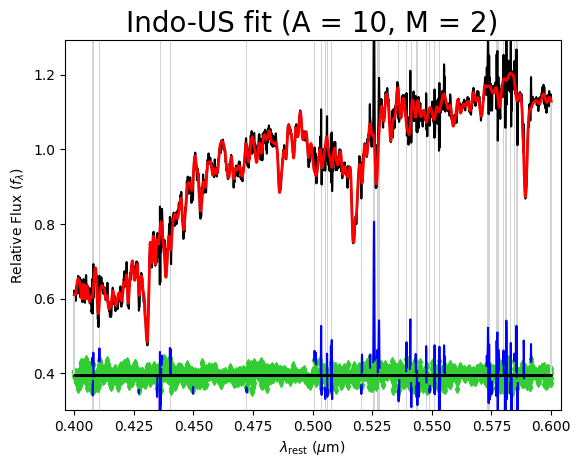

[  3.62182733 269.26790726]
Number of selected INDO-US templates: 15
non_zero_indices [129 295 364 404 444 448 449 456 533 556 587 625 731 734 758]


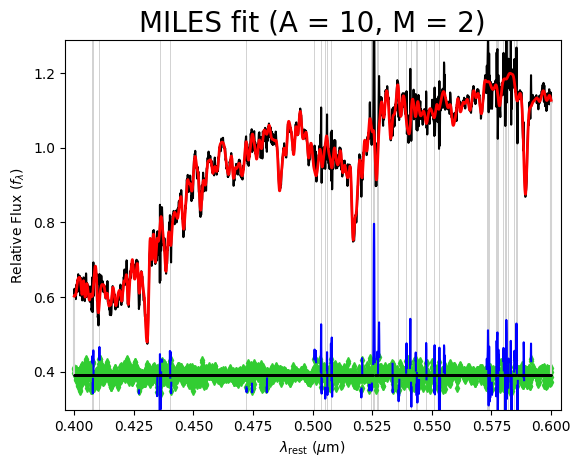

[  2.89394917 275.63981268]
Number of selected MILES templates: 20
non_zero_indices [ 66 110 120 128 129 200 273 334 335 343 419 432 452 546 593 710 737 757
 765 772]


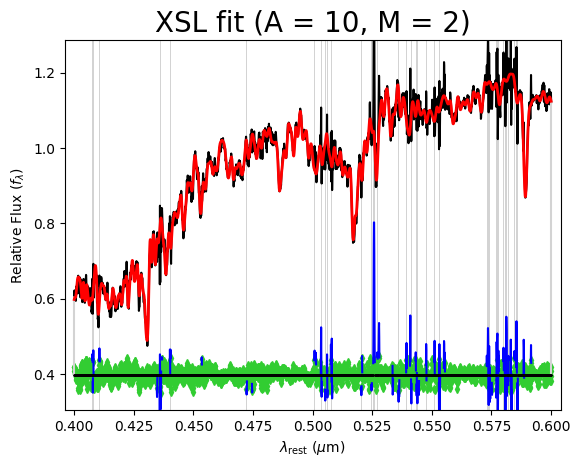

[  6.11937479 271.52238423]
Number of selected XSL templates: 20
non_zero_indices [ 52  60  95  96 125 156 248 249 250 257 269 321 328 351 363 368 427 434
 435 436]


Text(0.5, 1.0, 'Combined mask INDO-US fit (A = 10, M = 2)')

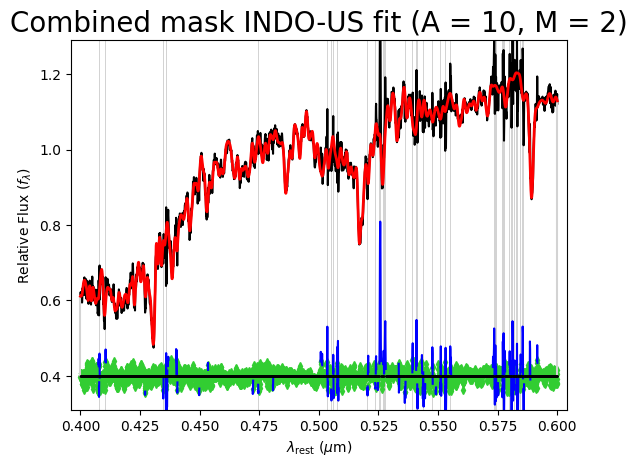

In [1226]:
# ======================
# fit the spectrum with ppxf at template level, to determine template weights
# ======================

# clip outliers method, see Cappellari (2023) https://ui.adsabs.harvard.edu/abs/2023MNRAS.526.3273C
def clip_outliers(galaxy, bestfit, mask, n_sig=3): # 2.5 if DESJ0206
    """
    Repeat the fit after clipping bins deviants more than n_sig*sigma in relative
    error until the bad bins don't change any more. This function uses eq.(34)
    of Cappellari (2023) https://ui.adsabs.harvard.edu/abs/2023MNRAS.526.3273C


    params
    - galaxy: observed spectrum
    - noise: noise spectrum
    - bestfit: best fit spectrum from ppxf
    - mask: boolean array of good pixels (initially all True)
    - n_sig: number of sigma for clipping (default 3)
    """
    while True: # loops until the mask is unchanged
        scale = galaxy[mask] @ bestfit[mask]/np.sum(bestfit[mask]**2) 
        resid = (scale*bestfit[mask] - galaxy[mask])
        err = robust_sigma(resid, zero=3)
        ok_old = mask
        mask = np.abs(scale*bestfit - galaxy) < n_sig*err
        if np.array_equal(mask, ok_old):
            break
    return mask

# apply the sigma clipping to the spectrum

n_iterations = 2

# all three templates
templates_all = [templates_indous, templates_miles, templates_xsl]
template_names = ['Indo-US', 'MILES', 'XSL']

velocities = []


# run the fit iteratively with sigma clipping, and then get noise rescaling from that result
masks = []
for template in templates_all:
    mask_0 = np.ones_like(integrated_spectrum.wavelengths, dtype=bool)
    mask_0 = mask_0 
    """& ~(
    (integrated_spectrum.wavelengths > masking_min) & 
    (integrated_spectrum.wavelengths < masking_max))""" # mask out the region around Fe5270 because of likely sky line issue
    
    for i in range(n_iterations):
        ppxf_fit = Pipeline.run_ppxf(integrated_spectrum, template, [vel_init, sigma_init], degree= additive, mdegree = multiplicative, mask = mask_0)
        mask_0 = mask_0 & clip_outliers(integrated_spectrum.flux, ppxf_fit.bestfit, mask_0)

    velocities.append(ppxf_fit.sol[0])

    # not needed any longer, because the KCWI resolution for RL7150 is lower than MILES at this deflector redshift. May need for other z_defl!!!!!!!! 
    """ # apply quadrature correction to the velocity dispersion to account for FWHM difference
    if template_names[templates_all.index(template)] == 'MILES':
        sigma_data = c * integrated_spectrum.fwhm / np.mean(integrated_spectrum.wavelengths) / 2.355 # convert FWHM in AA to sigma in km/s
        sigma_template = c * miles_instrumental_fwhm / np.mean(templates_miles.wavelengths) / 2.355
        resolution_difference = sigma_data**2 - sigma_template**2
        print(f"Resolution difference (sigma^2) between data and MILES template: {resolution_difference:.2f} (km/s)^2")
        ppxf_fit.sol[1] = np.sqrt(ppxf_fit.sol[1]**2 + resolution_difference)"""
    
    # plot the output
    ppxf_fit.plot()
    plt.title(f'{template_names[templates_all.index(template)]} fit (A = {additive}, M = {multiplicative})', fontsize=20)
    plt.show()
    print(ppxf_fit.sol)

    # add the mask
    masks.append(mask_0)

    if template == templates_indous:
        indous_weights = ppxf_fit.weights
        print(f"Number of selected INDO-US templates: {np.where(indous_weights > 0)[0].shape[0]}") # taken from knabel code
        refined_indous_templates = template.discard_zero_weights(indous_weights)
    if template == templates_miles:
        miles_weights = ppxf_fit.weights
        print(f"Number of selected MILES templates: {np.where(miles_weights > 0)[0].shape[0]}") # taken from knabel code
        refined_miles_templates = template.discard_zero_weights(miles_weights)
    if template == templates_xsl:
        xsl_weights = ppxf_fit.weights
        print(f"Number of selected XSL templates: {np.where(xsl_weights > 0)[0].shape[0]}") # taken from knabel code
        refined_xsl_templates = template.discard_zero_weights(xsl_weights)

# combine the masks from all three fits, and run ppxf showing the full mask, using INDO-US
total_mask = np.logical_and.reduce(masks)
ppxf_fit = Pipeline.run_ppxf(integrated_spectrum, templates_indous, [vel_init, sigma_init], degree= additive, mdegree = multiplicative, mask = total_mask)
ppxf_fit.plot()
plt.title(f'Combined mask INDO-US fit (A = {additive}, M = {multiplicative})', fontsize=20)

Indo-US sigma std: 1.32 km/s
Indo-US sigma median: 268.37 km/s


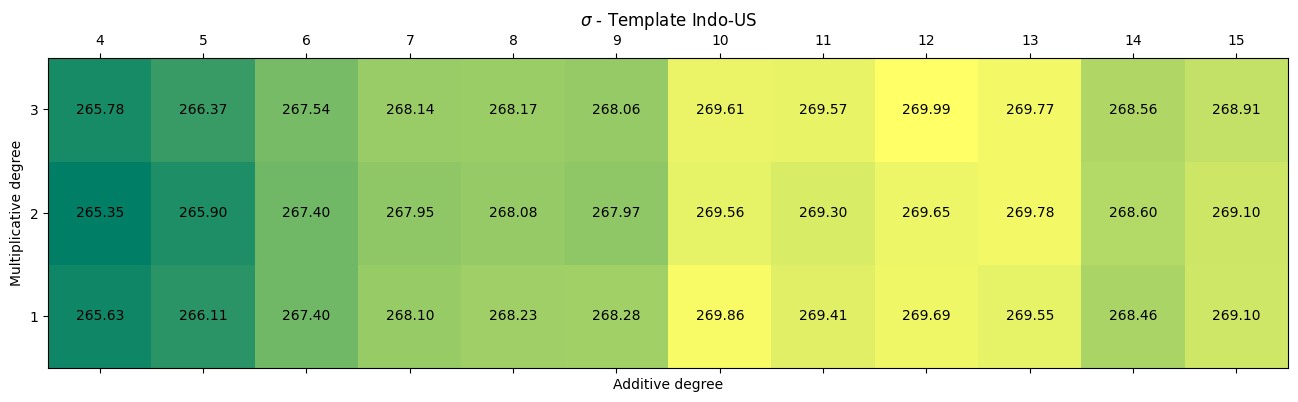

MILES sigma std: 0.89 km/s
MILES sigma median: 275.78 km/s


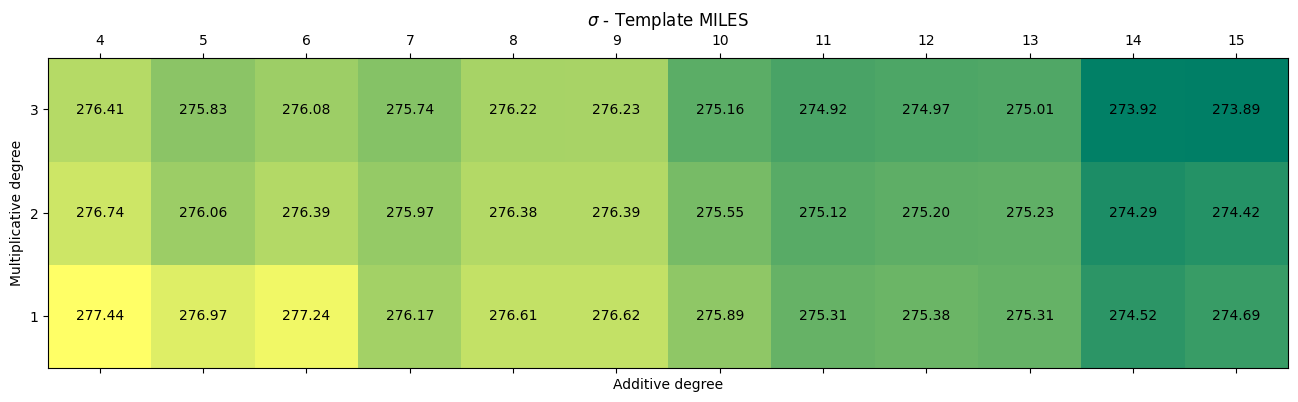

XSL sigma std: 1.94 km/s
XSL sigma median: 272.81 km/s


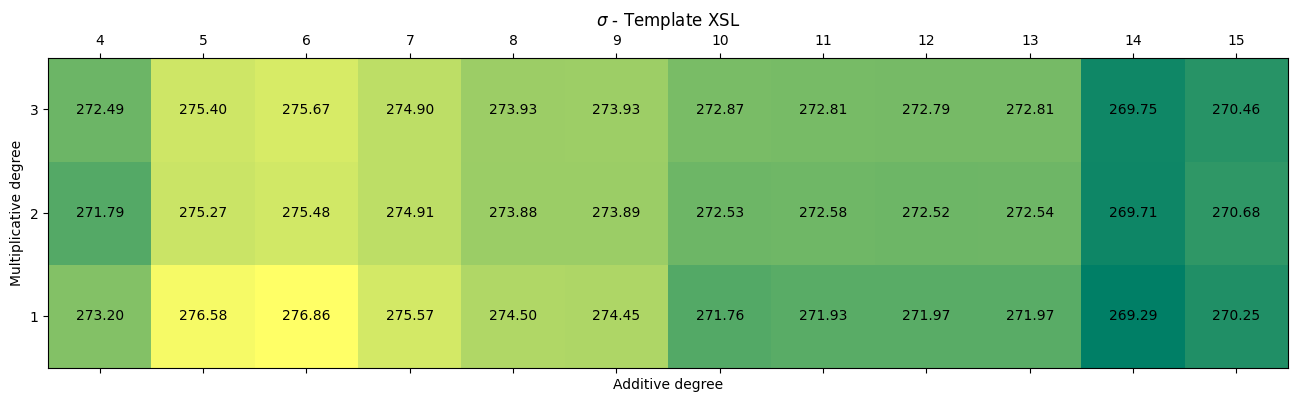

In [1227]:
# ======================
# Run all three libraries together, give varying sets of multiplicative/additive polynomials
# ======================

# use refined templates for the next round of fits
refined_templates_all = [refined_indous_templates, refined_miles_templates, refined_xsl_templates]

# initializing the arrays for the noise rescaling
diagnostic = []

# ==================
# run ppxf on everything
# ==================
for template in refined_templates_all:
    if template == refined_indous_templates:
        template_name = 'Indo-US'
    elif template == refined_miles_templates:
        template_name = 'MILES'
    elif template == refined_xsl_templates:
        template_name = 'XSL'

    # run masking iterations
    for j in degree:
        for m in mdegree:
            
            ppxf_fit = Pipeline.run_ppxf(integrated_spectrum, template, [vel_init, sigma_init], degree= j, mdegree = m, mask = total_mask)

            # account for the resolution difference between miles and our data
            if template == templates_miles:
                ppxf_fit.sol[1] = np.sqrt(ppxf_fit.sol[1]**2 + resolution_difference)
            

            # save info after final iteration
            diagnostic.append([template_name, ppxf_fit.sol[0], ppxf_fit.sol[1], ppxf_fit.chi2, j, m])

# scale the spectrum noise based on the avg chi^2
avg_red_chi2 = np.mean([row[3] for row in diagnostic])
noise_rescaling = np.sqrt(avg_red_chi2)
integrated_spectrum.noise = integrated_spectrum.noise * noise_rescaling


# =================
# rerun the fits with the rescaled noise, and save the diagnostic info again
# =================

# initialize arrays for BIC weighting
dispersions = np.zeros(
    (len(refined_templates_all), len(mdegree), len(degree)) # dispersion measurements
)
dispersion_uncertainties = np.zeros_like(dispersions) # dispersion uncertainties
velocities = np.zeros_like(dispersions) # velocity measurements
velocity_uncertainties = np.zeros_like(dispersions) # velocity uncertainties
ppxf_fits_array = [[[None for _ in degree] for _ in mdegree] 
                    for _ in refined_templates_all] # builds out array for BIC weighting
new_diagnostic = []

for i, template in enumerate(refined_templates_all):
    if template == refined_indous_templates:
        template_name = 'Indo-US'
    elif template == refined_miles_templates:
        template_name = 'MILES'
    elif template == refined_xsl_templates:
        template_name = 'XSL'

    for j, deg in enumerate(degree):
        for m, mdeg in enumerate(mdegree):
            
            ppxf_fit = Pipeline.run_ppxf(integrated_spectrum, template, [vel_init, sigma_init], degree= deg, mdegree = mdeg, mask = total_mask, plot = False)
            plt.show()

            # account for the resolution difference between miles and our data
            if template == templates_miles:
                ppxf_fit.sol[1] = np.sqrt(ppxf_fit.sol[1]**2 + resolution_difference)
            
            # save info for BIC weighting
            dispersions[i, m, j] = ppxf_fit.sol[1]
            velocities[i, m, j] = ppxf_fit.sol[0]
            dispersion_uncertainties[i, m, j] = ppxf_fit.error[1]
            velocity_uncertainties[i, m, j] = ppxf_fit.error[0]
            ppxf_fits_array[i][m][j] = ppxf_fit
            new_diagnostic.append([template_name, ppxf_fit.sol[0], ppxf_fit.sol[1], ppxf_fit.chi2, deg, mdeg])


# create diagnostic matpanels to show the variation of sigma by template/polynomial order
for i, template in enumerate(refined_templates_all):

    diag = np.array(new_diagnostic, dtype=object)
    template_diag = diag[diag[:, 0] == template_name]

    sigma_map = np.full((len(mdegree), len(degree)), np.nan)
    template_name = template_names[i]
    template_diag = diag[diag[:, 0] == template_name]

    sigma_map = np.full((len(mdegree), len(degree)), np.nan)

    for row in template_diag:
        j_val = int(row[4])
        m_val = int(row[5])
        ii = np.where(degree == j_val)[0]
        jj = np.where(mdegree == m_val)[0]
        if ii.size and jj.size:
            sigma_map[jj[0], ii[0]] = float(row[2])
    
    std_template = np.nanstd(sigma_map)
    median_template = np.nanmedian(sigma_map)
    print(f"{template_name} sigma std: {std_template:.2f} km/s")
    print(f"{template_name} sigma median: {median_template:.2f} km/s")

    plt.matshow(sigma_map, cmap="summer", origin="lower")
    for k in range(len(mdegree)):
        for l in range(len(degree)):
            val = sigma_map[k, l]
            txt = "-" if np.isnan(val) else f"{val:.2f}"
            plt.text(l, k, txt, ha="center", va="center", color="k")

    plt.xlabel("Additive degree")
    plt.ylabel("Multiplicative degree")
    plt.title(
        r"$ {\sigma}$ - Template %s" % (template_name)
    )
    plt.xticks(range(len(degree)), [f"{l}" for l in degree])
    plt.yticks(range(len(mdegree)), [f"{k}" for k in mdegree])
    # plt.savefig(
    #     os.path.join(
    #         outputfolder,
    #         f"dispersion_object_{k}_template_{i}.png",
    #     ),
    #     bbox_inches="tight",
    # )
    plt.show()


In [1228]:
# ======================
# Run the BIC analysis on ppxf fits for different polynomial degrees and templates
# ======================

# template 0 is INDO-US, template 1 is MILES, template 2 is XSL

# convert nested list of ppxf fits to an object ndarray before reshaping
ppxf_fits_arr = np.array(ppxf_fits_array, dtype=object)



In [1229]:
"""weightings = np.zeros_like(ppxf_fits_arr, dtype=float)
for m in range(ppxf_fits_arr.shape[1]):
    for j in range(ppxf_fits_arr.shape[2]):
        # calculate the relative bic weights
        fits = ppxf_fits_arr[:, m, j][:, np.newaxis]      
        bic_weights = Pipeline.get_relative_bic_weights_for_sample(fits,
                            num_bootstrap_samples=100)
        print(f"Relative BIC weights for m={m}, j={j}: {bic_weights}")
        weightings[:, m, j] = bic_weights

print(np.mean(weightings, axis=(1,2))) # might overestimate the errors in the end by doing this. Kinda shot yourself in the foot by doing this
# whole grid to identify where m"""

'weightings = np.zeros_like(ppxf_fits_arr, dtype=float)\nfor m in range(ppxf_fits_arr.shape[1]):\n    for j in range(ppxf_fits_arr.shape[2]):\n        # calculate the relative bic weights\n        fits = ppxf_fits_arr[:, m, j][:, np.newaxis]      \n        bic_weights = Pipeline.get_relative_bic_weights_for_sample(fits,\n                            num_bootstrap_samples=100)\n        print(f"Relative BIC weights for m={m}, j={j}: {bic_weights}")\n        weightings[:, m, j] = bic_weights\n\nprint(np.mean(weightings, axis=(1,2))) # might overestimate the errors in the end by doing this. Kinda shot yourself in the foot by doing this\n# whole grid to identify where m'

In [1230]:
arr = ppxf_fits_arr.reshape(-1, 1)
print(arr.shape)

(108, 1)


In [1231]:
(
    combined_values_final,
    combined_systematic_uncertainty_final,
    combined_statistical_uncertainty_final,
    covariance_final,
) = Pipeline.combine_measurements_from_templates(
    dispersions.reshape(-1, 1),
    dispersion_uncertainties.reshape(-1, 1),
    ppxf_fits_arr.reshape(-1, 1),
    verbose=True,
    weight_threshold=0.01,
    num_bootstrap_samples=100,
    apply_bic_weighting=True,
    do_bessel_correction=True,
    num_fixed_parameters=0,
)

BIC weighting  applied
Weights: [6.25762938e-34 1.70054058e-34 1.14437084e-33 2.28384203e-34
 4.70953787e-36 1.85581984e-37 4.05113361e-39 2.90453068e-26
 1.79330128e-27 1.02592375e-01 7.85470200e-01 8.62967502e-02
 3.34536471e-35 5.20136156e-36 2.19335511e-35 6.13600701e-36
 1.27120479e-37 1.05424243e-38 4.71314201e-37 6.30075674e-28
 3.46147240e-29 3.96101244e-03 1.79428122e-02 1.65092382e-03
 6.35271945e-36 2.48520601e-38 7.89311207e-37 2.55646381e-37
 4.96390351e-39 2.79378087e-40 9.03424993e-39 1.77500363e-30
 4.20027756e-28 2.02706565e-04 1.81172981e-03 7.14896157e-05
 6.66328188e-14 2.48488923e-14 1.89219553e-17 2.78353436e-18
 1.54172421e-20 2.94873533e-22 5.53668307e-23 2.40116511e-20
 1.24403843e-19 2.30684498e-18 1.21588380e-18 1.43726198e-18
 2.49541205e-15 2.65744289e-17 8.84857975e-19 6.16937303e-20
 1.83750657e-20 3.53309938e-22 1.47661107e-24 5.26219774e-22
 2.69974512e-21 8.57224426e-22 2.78210973e-20 4.05599730e-20
 2.45343812e-15 2.19347898e-16 6.59673481e-18 4.88909

In [1233]:
# weights: 1D array returned by Pipeline.combine_measurements_from_templates
# ppxf_fits_arr shape is (n_templates, len(mdegree), len(degree))


weights = np.array([
    6.25762938e-34, 1.70054058e-34, 1.14437084e-33, 2.28384203e-34,
    4.70953787e-36, 1.85581984e-37, 4.05113361e-39, 2.90453068e-26,
    1.79330128e-27, 1.02592375e-01, 7.85470200e-01, 8.62967502e-02,
    3.34536471e-35, 5.20136156e-36, 2.19335511e-35, 6.13600701e-36,
    1.27120479e-37, 1.05424243e-38, 4.71314201e-37, 6.30075674e-28,
    3.46147240e-29, 3.96101244e-03, 1.79428122e-02, 1.65092382e-03,
    6.35271945e-36, 2.48520601e-38, 7.89311207e-37, 2.55646381e-37,
    4.96390351e-39, 2.79378087e-40, 9.03424993e-39, 1.77500363e-30,
    4.20027756e-28, 2.02706565e-04, 1.81172981e-03, 7.14896157e-05,
    6.66328188e-14, 2.48488923e-14, 1.89219553e-17, 2.78353436e-18,
    1.54172421e-20, 2.94873533e-22, 5.53668307e-23, 2.40116511e-20,
    1.24403843e-19, 2.30684498e-18, 1.21588380e-18, 1.43726198e-18,
    2.49541205e-15, 2.65744289e-17, 8.84857975e-19, 6.16937303e-20,
    1.83750657e-20, 3.53309938e-22, 1.47661107e-24, 5.26219774e-22,
    2.69974512e-21, 8.57224426e-22, 2.78210973e-20, 4.05599730e-20,
    2.45343812e-15, 2.19347898e-16, 6.59673481e-18, 4.88909511e-21,
    6.95156581e-21, 1.36318203e-22, 7.09856337e-23, 1.68853264e-22,
    1.36121276e-21, 1.89436587e-20, 3.19137041e-20, 6.13859859e-22,
    3.48737430e-76, 9.20917840e-73, 3.07238999e-72, 1.60597120e-72,
    2.55155268e-69, 1.28665175e-70, 4.17126739e-31, 1.26636632e-28,
    5.60932535e-30, 1.07141769e-31, 5.19413937e-21, 5.97149547e-20,
    1.79521252e-75, 1.31002756e-70, 3.16142113e-72, 4.20120423e-75,
    1.88813358e-68, 5.33563586e-70, 1.73622828e-30, 8.06887359e-30,
    5.25045473e-33, 5.59106028e-33, 1.09866543e-20, 3.82107228e-23,
    1.73050223e-73, 3.16730606e-71, 7.94709102e-73, 2.93164637e-73,
    6.32890448e-70, 1.72377119e-71, 2.34683235e-29, 3.38044387e-33,
    5.94181963e-33, 3.49597409e-36, 3.64947653e-20, 4.56341247e-23
], dtype=float)

n_templates = len(template_names)
n_m = len(mdegree)
n_d = len(degree)

def decode_weight_position(pos):
    t_idx = pos // (n_m * n_d)
    rem = pos % (n_m * n_d)
    m_idx = rem // n_d
    d_idx = rem % n_d

    return {
        "template": template_names[t_idx],
        "multiplicative_degree": int(mdegree[m_idx]),
        "additive_degree": int(degree[d_idx]),
    }

# example: decode the highest-weight model
best_pos = np.argmax(weights)
print(best_pos, decode_weight_position(best_pos))

mdegree_ideal = []
degree_ideal = []
template_ideal = []

# if needed, list all non-zero weights
for pos in np.where(weights > 0.01)[0]:
    print(pos, weights[pos], decode_weight_position(pos))
    model = decode_weight_position(pos)
    mdegree_ideal.append(model["multiplicative_degree"])
    degree_ideal.append(model["additive_degree"])
    template_ideal.append(model["template"])

10 {'template': 'Indo-US', 'multiplicative_degree': 1, 'additive_degree': 14}
9 0.102592375 {'template': 'Indo-US', 'multiplicative_degree': 1, 'additive_degree': 13}
10 0.7854702 {'template': 'Indo-US', 'multiplicative_degree': 1, 'additive_degree': 14}
11 0.0862967502 {'template': 'Indo-US', 'multiplicative_degree': 1, 'additive_degree': 15}
22 0.0179428122 {'template': 'Indo-US', 'multiplicative_degree': 2, 'additive_degree': 14}


In [1234]:
print(' ### BIC-weighted measurement ### ')
print('BIC combined sigma_v', combined_values_final)
print('BIC combined sigma_v uncertainties (sys)', combined_systematic_uncertainty_final)
print('BIC combined sigma_v uncertainties (stat)', combined_statistical_uncertainty_final)
#print('BIC combined sigma_v covariances', covariance_final)

template_final = []
# ======================
# obtain template objects from ideal template
# ====================
indous, miles, xsl = 0,0,0
for temp in template_ideal:
    if temp == 'Indo-US':
        indous += 1
    elif temp == 'MILES':
        miles += 1
    elif temp == 'XSL':
        xsl += 1

if indous > 0:
    template_final.append(refined_indous_templates)
if miles > 0:
    template_final.append(refined_miles_templates)
if xsl > 0:
    template_final.append(refined_xsl_templates)

# ======================
# obtain final velocity dispersion measurement of integrated spectrum
# ======================

final_sigma_stat_uncertainty = combined_statistical_uncertainty_final # avg statistical uncertainty after BIC weighting
final_sigma_sys_uncertainty = combined_systematic_uncertainty_final # avg systematic uncertainty after BIC weighting
total_uncertainty = np.sqrt(final_sigma_stat_uncertainty**2 + final_sigma_sys_uncertainty**2) # combine systematic and statistical uncertainty in quadrature

print(f"Final velocity dispersion measurement: {combined_values_final[0]:.2f} ± {total_uncertainty[0]:.2f} km/s")

 ### BIC-weighted measurement ### 
BIC combined sigma_v [268.63649377]
BIC combined sigma_v uncertainties (sys) [0.60587978]
BIC combined sigma_v uncertainties (stat) [2.73866036]
Final velocity dispersion measurement: 268.64 ± 2.80 km/s


In [1235]:
# ======================
# apply to finding the LOS velocity, to find the true redshift
# ======================

# obtain the ppxf fits from the ideal template combinations
ppxf_fits_ideal = []
velocities_for_fit = []
velocity_uncertainties_for_fit = []
for pos in np.where(weights > 0.01)[0]:
    model = decode_weight_position(pos)
    template_name = model["template"]
    mdeg = model["multiplicative_degree"]
    deg = model["additive_degree"]

    if template_name == 'Indo-US':
        template_idx = 0
    elif template_name == 'MILES':
        template_idx = 1
    elif template_name == 'XSL':
        template_idx = 2

    m_idx = np.where(mdegree == mdeg)[0][0]
    d_idx = np.where(degree == deg)[0][0]
    
    ppxf_fit = ppxf_fits_array[template_idx][m_idx][d_idx]
    velocities_for_fit.append(velocities[template_idx, m_idx, d_idx])
    velocity_uncertainties_for_fit.append(velocity_uncertainties[template_idx, m_idx, d_idx])
    ppxf_fits_ideal.append(ppxf_fit)

ppxf_fits_ideal = np.array(ppxf_fits_ideal, dtype=object).reshape(-1, 1)
velocities_for_fit = np.array(velocities_for_fit).reshape(-1, 1)
velocity_uncertainties_for_fit = np.array(velocity_uncertainties_for_fit).reshape(-1, 1)

# only apply the BIC weighting for the ppxf fits weighed highly in the dispersion measurement (decrease systematics)
# get the velocity measurements from the ideal ppxf fits, and apply BIC weighting to get the final velocity measurement
(
    combined_velocity_final,
    combined_velocity_sys_uncertainty_final,
    combined_velocity_stat_uncertainty_final,
    covariance_final,
) = Pipeline.combine_measurements_from_templates(
    velocities_for_fit,
    velocity_uncertainties_for_fit,
    ppxf_fits_ideal,
    verbose=True,
    weight_threshold=0.01,
    num_bootstrap_samples=100,
    apply_bic_weighting=True,
    do_bessel_correction=True,
    num_fixed_parameters=0,
)

BIC weighting  applied
Weights: [0.10338824 0.79156355 0.0869662  0.018082  ]


In [1236]:
total_velocity_uncertainty = np.sqrt(combined_velocity_sys_uncertainty_final**2 + combined_velocity_stat_uncertainty_final**2)
print(f"Final velocity measurement: {combined_velocity_final[0]:.2f} ± {total_velocity_uncertainty[0]:.2f} km/s")

# obtain the best fit redshift from this value
c = 299792.458 # speed of light in km/s
z_los = np.sqrt((1 + combined_velocity_final[0] / c) / (1 - combined_velocity_final[0] / c)) - 1 # relativistic Doppler formula
z_los_uncertainty = (1 + z_los) * total_velocity_uncertainty / c # propagate velocity uncertainty to redshift uncertainty
z_los_uncertainty = float(z_los_uncertainty)
z_true = z_defl + z_los + z_defl * z_los # relativistic addition of velocities
print(f"z_true = {z_true:.6f} ± {z_los_uncertainty:.6f}")

Final velocity measurement: 6.26 ± 2.61 km/s
z_true = 0.445305 ± 0.000009


/var/folders/5k/qcywytnj7rdc1xdk_bq2qy8m0000gn/T/ipykernel_49984/823165523.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z_los_uncertainty = float(z_los_uncertainty)


In [1240]:
# ======================
# Save all of the information from the ppxf fits and BIC analysis
# ======================

# save the combined values, uncertainties, covariance, and template uncertainty in a pickle file
pickle_filename = f"{obj}_{filter}_combined_backup.pkl"
pickle_path = os.path.join(gen_dir, '..', 'kinematics_outputs', pickle_filename)

save_data = {
    'combined_values_final': combined_values_final,
    'combined_systematic_uncertainty_final': combined_systematic_uncertainty_final,
    'combined_statistical_uncertainty_final': combined_statistical_uncertainty_final,
    'covariance_final': covariance_final,
    'z_defl': z_true,
    'z_defl_err': z_los_uncertainty,

    'ideal_ppxf_fits': ppxf_fits_ideal,

    "degree_ideal": degree_ideal,
    "mdegree_ideal": mdegree_ideal,
    "templates_choices": template_final, # only save the template that had BIC weight above 0.01
    "mask": total_mask,
    "noise_rescaling": noise_rescaling,
}

with open(pickle_path, 'wb') as f:
        pkl.dump(save_data, f)